In [16]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/root/workspace/vllm-dynamic/examples/logs/'
BASELINE_DATA_PATH = f'{DATA_PATH}dllm_org_128'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']
scheduling_policy = 'fcfs'
wt = 1.0

In [17]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR):
    output_tokens, reqs, mean_tpot, p99_tpot,  mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []

    filename = f'{DATA_DIR}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_recompute_{store_cache_layer}_{scheduling_policy}_wt{wt}.log'
    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft_, p99_ttft_, mean_itl_, p99_itl_ = [], [], [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean TTFT' in line:
                mean_ttft_.append(float(line.split()[-1]))
            if 'P99 TTFT' in line:
                p99_ttft_.append(float(line.split()[-1]))    
            if 'Mean ITL' in line:
                mean_itl_.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl_.append(float(line.split()[-1]))    

    output_tokens.append(np.mean(output_tokens_tgt))
    reqs.append(np.mean(reqs_tgt))
    mean_tpot.append(np.mean(mean_tpot_))
    p99_tpot.append(np.mean(p99_tpot_))
    mean_ttft.append(np.mean(mean_ttft_))
    p99_ttft.append(np.mean(p99_ttft_))
    mean_itl.append(np.mean(mean_itl_))
    p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl 

In [18]:
# plot throughput
def get_norm_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, DATA_DIR)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_ttft, baseline_p99_ttft, baseline_mean_itl, baseline_p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layer, BASELINE_DATA_PATH)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [(baseline_mean_tpot-mean_tpot[i]) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [(baseline_p99_tpot-p99_tpot[i]) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_ttft_imp = [(baseline_mean_ttft-mean_ttft[i]) / baseline_mean_ttft *100 for i in range(len(mean_ttft))]
    p99_ttft_imp = [(baseline_p99_ttft-p99_ttft[i]) / baseline_p99_ttft *100 for i in range(len(p99_ttft))]
    mean_itl_imp = [(baseline_mean_itl-mean_itl[i]) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [(baseline_p99_itl-p99_itl[i]) / baseline_p99_itl *100 for i in range(len(p99_itl))]

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp
    

In [19]:
# 绘制柱状图，对比swap和recompute的性能提升
def plot_bar(rate1, rate2, store_cache_layer):
    print('rate1:', rate1)
    print('rate2:', rate2)
    fig = plt.figure(figsize=(6, 2.5), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    ax.bar(np.arange(8), rate1, bar_width, label='0.5:0.5', color='skyblue', hatch=hatches[0])
    ax.bar(np.arange(8)+bar_width, rate2, bar_width, label='0.25:0.75', color='lightcoral', hatch=hatches[1])
    # bar3 = ax.bar(np.arange(8)+bar_width*2, rate3, bar_width, label='0.25:0.75', color='lightgreen', hatch=hatches[2])
    # 将数值标注在柱状图上
    for x, y in zip(np.arange(8), rate1):
        if y >= 0: ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=20, fontsize=8)
        else: ax.text(x, y, f'{y:.2f}', ha='center', va='top', rotation=70, fontsize=8)
    for x, y in zip(np.arange(8)+bar_width, rate2):
        if y >= 0: ax.text(x, y, f'{y:.2f}', ha='center', va='bottom', rotation=20, fontsize=8)
        else: ax.text(x, y, f'{y:.2f}', ha='center', va='top', rotation=70, fontsize=8)
    # for x, y in zip(np.arange(8)+bar_width*2, rate3):
    #     if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
    #     else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    ax.set_xticks(np.arange(8)+bar_width)
    ax.set_xticklabels(['out_toks', 'reqs', 'avg_tpot', 'p99_tpot', 'avg_ttft', 'p99_ttft', 'avg_itl', 'p99_itl'], rotation=0)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(plt.MultipleLocator(30))
    # ax.set_ylim(min(min(rate1), min(rate2), min(rate3))*1.4, max(max(rate1), max(rate2), max(rate3))*1.4)
    ax.set_ylim(min(min(rate1), min(rate2))*1.4, max(max(rate1), max(rate2))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    ax.title.set_text(f'{store_cache_layer} cache layer')
    # ax.legend(bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()    

rate1: [2.2236708457771748, 3.2692307692307936, -4.51516563585528, -3.155126763628428, 2.9505986229019716, 1.8746405856518655, -0.02749950893731818, -5.314858753792618]
rate2: [-0.3767263465882452, 0.769230769230787, -4.727611624163329, -2.9331090638714348, 2.90030551946499, 1.8858904118937914, -1.5222942447456267, -4.778478658057699]


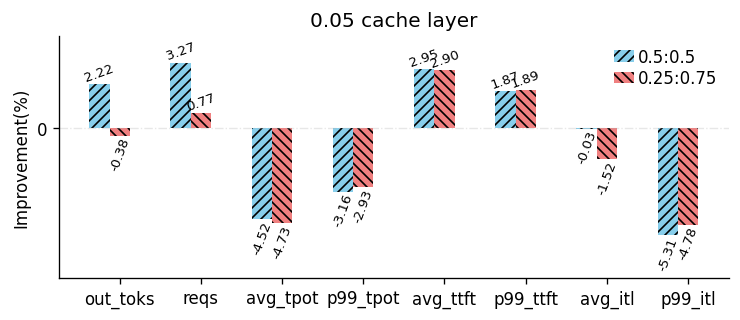

rate1: [-12.334825853641853, 9.188118811881179, -4.054893544925728, 2.9419912947178406, -2.260811067817412, -0.4944467363098103, 25.205968941726432, 21.170716163466906]
rate2: [-20.121680281641993, 0.0, -11.91744633321412, -3.761170928108411, -9.547805303067209, -8.680471089227503, 19.735038317189936, 12.130964709631144]


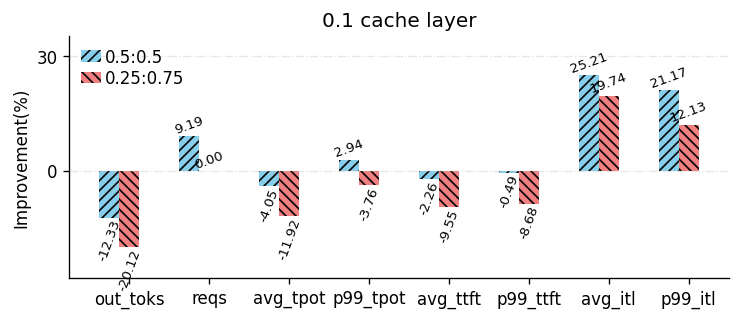

rate1: [-11.068260425440405, 0.7228915662650609, -16.082031920370707, -12.444027032375853, -20.95274880780661, -16.582302356696278, -8.106842787275845, -16.47277468686024]
rate2: [-8.524936829089077, 3.6144578313253044, -6.738524903961658, 0.337494832769082, -3.405527402136622, -1.2719109292942055, -1.818333821009068, -6.456903824936727]


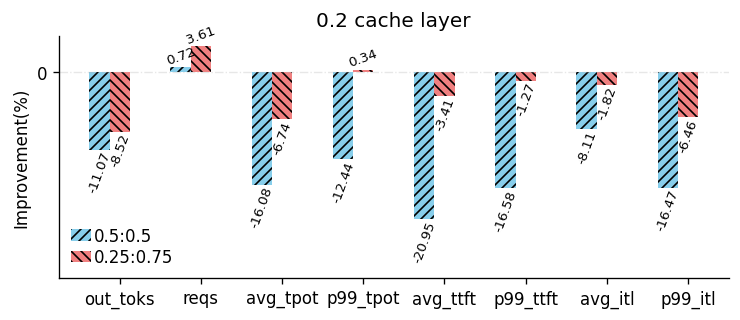

rate1: [32.462069052642256, 6.744186046511621, 5.21279574408512, -29.524615523353003, 0.3875515030153232, 13.933584192573326, 0.4667484040079539, 37.46992796822418]
rate2: [29.78132066652351, 4.457364341085271, 2.2749545009100016, -35.45509409879506, -5.312107931088394, 9.327461196164574, -2.0716188221367413, 36.4970404182217]


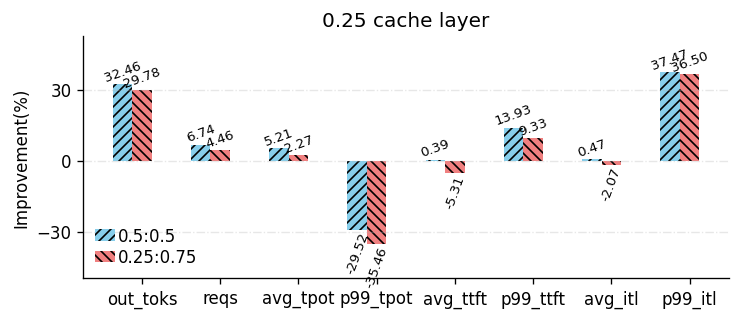

rate1: [78.42904769211454, 29.44543828264757, 29.110895389225266, -9.825367453792325, -90.64624189312302, -211.87868034027025, 32.66875882629843, 25.050658081621062]
rate2: [76.59194576573812, 29.159212880143105, 31.728325094128945, -4.618317667921296, -78.04346461827437, -195.2274784149525, 34.8611329044406, 29.858678155477698]


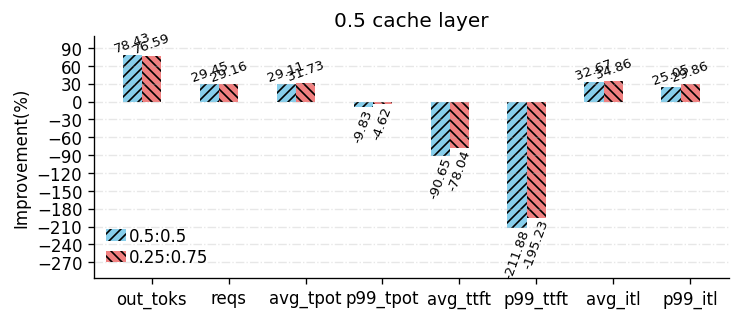

In [20]:
model_name = 'meta-llama_Llama-2-13b-hf'
gpu_utilization = 0.7
rates = ['0.5:0.5', '0.75:0.25']
num_threads = [64, 32]
store_cache_layers = [0.05, 0.1, 0.2, 0.25, 0.5]
# store_cache_layers = [0.05]
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 300, 300, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer)    


rate1: [-2.7816876803130626, -2.7603513174403895, -4.799385491971038, -7.676101091024279, -11.804978460499596, -10.096922840612349, -3.249879430403852, -0.6002679699751816]
rate2: [1.4469966957164255, 1.6311166875784342, 0.27759816814378613, -1.369648647049713, -2.7318088119136235, -2.594456675712097, 1.8529643198605605, 8.641651060460728]


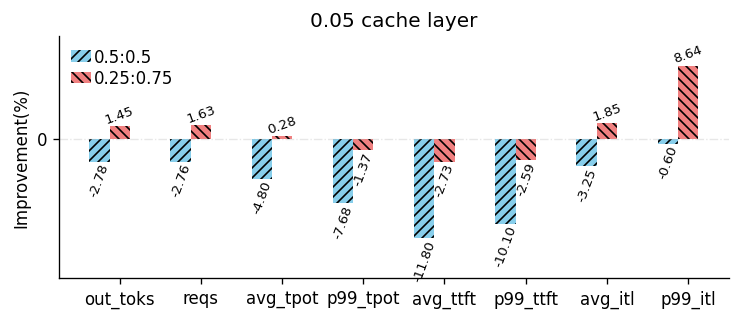

rate1: [0.010459430484022928, 1.3408490635569524e-14, 2.3899699200659725, 2.798414403467255, 3.1577366830291345, 3.1666833206714977, 1.555600731856054, -0.6592491925117997]
rate2: [-0.39832997759940564, -0.3623188405797105, 2.0743560510908283, 2.1507500947714893, 2.9040830314124104, 2.7529468424883343, 1.1660906688351156, -1.1413481830134646]


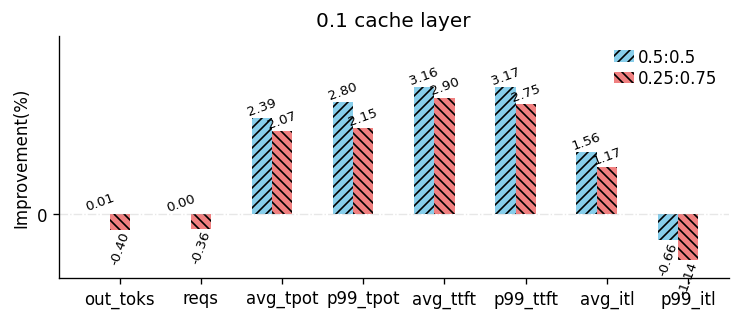

rate1: [-3.7684028997540877, -3.484688489968313, -2.9128145070174023, -3.97015567438119, -7.253254892447034, -6.029870165160714, -3.6081141635931053, -6.083140570484727]
rate2: [-7.40107942388144, -8.2365364308342, -3.554309351410798, -2.0296032036343594, -3.372654860100291, -3.4834448057060894, -5.138568129330236, -5.547720615767967]


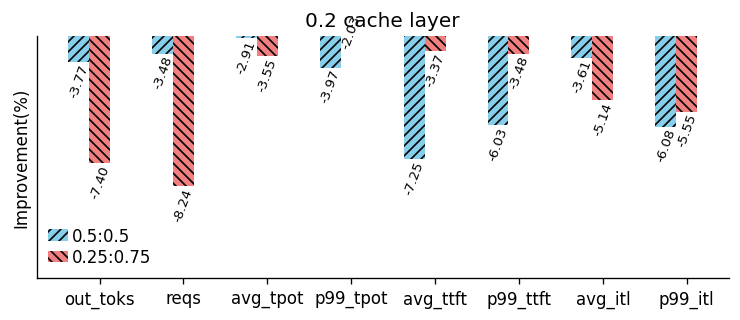

rate1: [3.764752902135793, 3.6994219653179097, -0.41855390153280075, -3.946668822847668, -4.366552813196656, -4.472248170428174, 2.4117768234902606, 1.6284343065020652]
rate2: [4.670061827452368, 4.161849710982662, 3.579986597854977, 2.9458823068196636, 4.21641102106457, 3.8048441998955145, 3.707988020346368, 5.386123281694546]


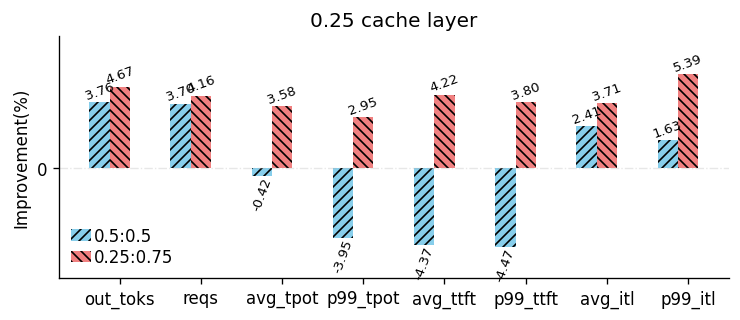

rate1: [-0.20457330854221387, -0.33444816053511733, -3.0663159297407585, -3.761086019399446, -2.8735728767128177, -2.47438898600489, -1.943921501511759, -6.576292455789834]
rate2: [-1.992609264980676, -2.006688963210686, -0.2127124039462897, 0.5181224145810156, 0.2522464694276173, -0.01604249674410262, -0.3779451195162107, -4.553935571223361]


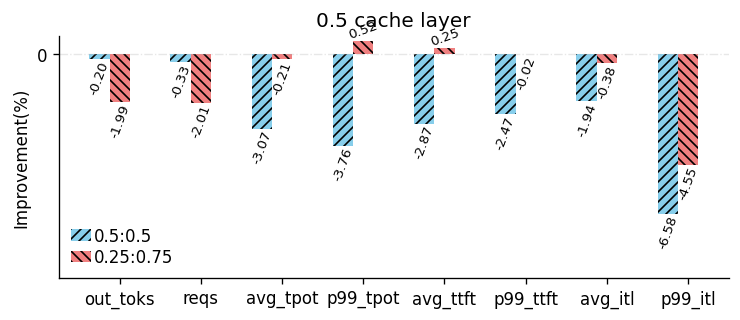

In [21]:
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 100, 300, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer)    

rate1: [-0.8114703131449963, -0.7874015748031503, 0.4850619876702304, -1.564089291100007, -2.634700607777045, -1.448178354682846, 0.5521850982152102, -1.2417576775537116]
rate2: [-1.0168198515004239, -0.9186351706036608, 3.511505543888202, 4.612762809605244, 5.178849035088381, 5.956253661689603, 0.9376728082899793, 1.30960326832382]


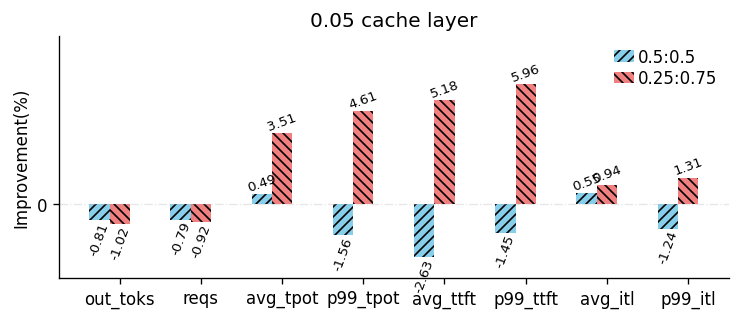

rate1: [1.3848001067283466, 0.9815950920245682, -3.3481032762321576, -6.433562319259507, -8.254990045601092, -7.772402159406293, -1.2852561268698137, -1.0985796142361377]
rate2: [0.2952817183261636, -0.12269938650304037, -0.122565927313933, -0.6308091162916835, -4.9292313848367275, -3.1956342941696207, 0.21380746075508222, -7.0528340462163355]


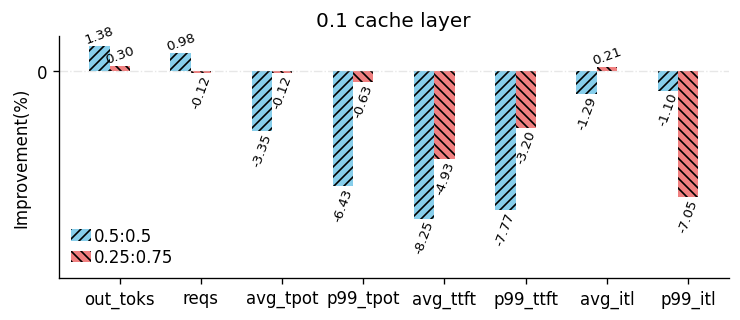

rate1: [-8.254924601858962, -8.040770101925263, -10.526759221949531, -11.876246567326051, -13.119250309602695, -12.862656157927631, -7.766399341969972, -16.45746070198469]
rate2: [-2.095599583852579, -2.0385050962627425, -0.28206161397854823, 0.25703110948852154, -0.32525902021006364, 0.4759356241784847, -1.3415587086160692, -7.170069224054515]


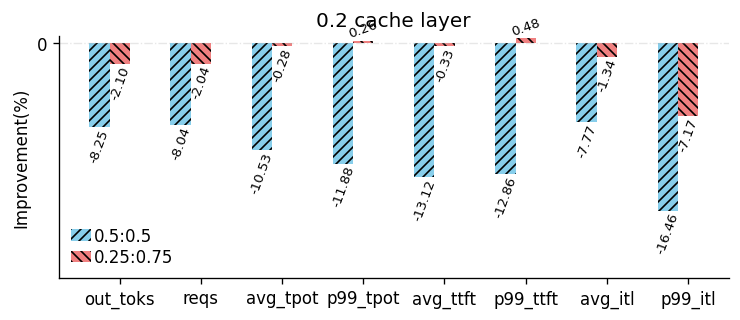

rate1: [-0.3744753726663014, -0.45819014891179877, -3.145170631034741, -8.412880774885686, -11.545809151532875, -10.843669888708881, 0.7780811540222048, 2.9017533252720646]
rate2: [3.3545998359786084, 3.2073310423826045, 0.7949795200640147, -1.8422744165084355, -2.8648826024216913, -2.8011226351576246, 3.366424141033143, 3.1402660217654277]


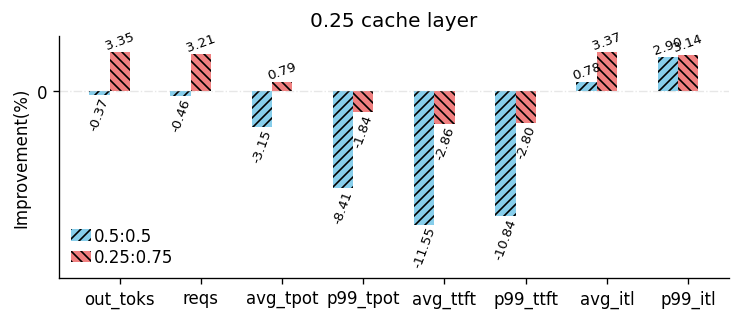

rate1: [-4.615684174658034, -3.9723661485319743, -2.7188055115464063, -2.159463106050981, -0.4105327490208756, 0.42124889507513297, -1.5359029544120377, -5.632805206844103]
rate2: [-0.9818429635399037, -1.122625215889456, -1.8262998703730247, -1.2918451303372709, -0.010622241111382701, -0.4687723769552753, -1.4813986639461139, -2.716685271864365]


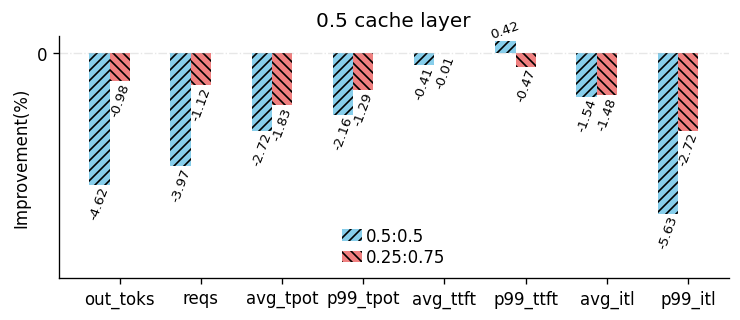

In [22]:
for store_cache_layer in store_cache_layers:
    output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = [], [], [], [], [], [], [], []
    rate_values = []
    for i in range(len(num_threads)):
        DATA_DIR = f'{DATA_PATH}dllm_org_128_hfusion_{num_threads[i]}'
        output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp = get_norm_res(model_name, gpu_utilization, 200, 300, store_cache_layer, DATA_DIR)
        output_tokens_imps.append(np.mean(output_tokens_imp))
        reqs_imps.append(np.mean(reqs_imp))
        mean_tpot_imps.append(np.mean(mean_tpot_imp))
        p99_tpot_imps.append(np.mean(p99_tpot_imp))
        mean_ttft_imps.append(np.mean(mean_ttft_imp))
        p99_ttft_imps.append(np.mean(p99_ttft_imp))
        mean_itl_imps.append(np.mean(mean_itl_imp))
        p99_itl_imps.append(np.mean(p99_itl_imp))
        rate_values.append([np.mean(output_tokens_imp), np.mean(reqs_imp), np.mean(mean_tpot_imp), np.mean(p99_tpot_imp), np.mean(mean_ttft_imp), np.mean(p99_ttft_imp), np.mean(mean_itl_imp), np.mean(p99_itl_imp)])
    plot_bar(rate_values[0], rate_values[1], store_cache_layer)    